In [ ]:
## live data on trades and book


import websocket
import json
import pandas as pd
import time
import os

trade_buffer = []
book_buffer = []
last_flush = time.time()
FLUSH_INTERVAL = 60
os.makedirs("live_data", exist_ok=True)
stop_requested = False

def parse_depth(data):
    row = {'timestamp': data['T']}
    for i, (price, size) in enumerate(data['b'][:20]):
        row[f'bid_{i}_price'] = float(price)
        row[f'bid_{i}_size'] = float(size)
    for i, (price, size) in enumerate(data['a'][:20]):
        row[f'ask_{i}_price'] = float(price)
        row[f'ask_{i}_size'] = float(size)
    return row

def parse_trade(data):
    return {
        'timestamp': data['T'],
        'price': float(data['p']),
        'amount': float(data['q']),
        'side': 'sell' if data['m'] else 'buy'
    }

def flush_to_disk():
    global trade_buffer, book_buffer
    ts_tag = int(time.time())
    if trade_buffer:
        pd.DataFrame(trade_buffer).to_parquet(f"live_data/trades_{ts_tag}.parquet")
        print(f"Yazıldı: {len(trade_buffer)} trade")
        trade_buffer = []
    if book_buffer:
        pd.DataFrame(book_buffer).to_parquet(f"live_data/book_{ts_tag}.parquet")
        print(f"Yazıldı: {len(book_buffer)} book update")
        book_buffer = []

def on_message(ws, message):
    global last_flush
    msg = json.loads(message)
    stream = msg['stream']
    data = msg['data']

    if stream.endswith('@trade'):
        t = parse_trade(data)
        if t['price'] > 0:
            trade_buffer.append(t)
    elif 'depth' in stream:
        book_buffer.append(parse_depth(data))

    if time.time() - last_flush > FLUSH_INTERVAL:
        flush_to_disk()
        last_flush = time.time()

def on_open(ws):
    print("Bağlantı açıldı!")

def on_error(ws, error):
    print(f"Hata: {error}")

def on_close(ws, close_status_code, close_msg):
    print("Bağlantı kapandı.")

streams = "btcusdt@trade/btcusdt@depth20@100ms"
url = f"wss://fstream.binance.com/stream?streams={streams}"

while not stop_requested:
    try:
        ws = websocket.WebSocketApp(
            url,
            on_message=on_message,
            on_open=on_open,
            on_error=on_error,
            on_close=on_close
        )
        ws.run_forever()
    except KeyboardInterrupt:
        stop_requested = True
        print("Manuel olarak durduruldu, veriler diske yazılıyor...")
        break
    except Exception as e:
        print(f"Beklenmeyen hata: {e}")

    if not stop_requested:
        print("5 saniye sonra yeniden bağlanılacak...")
        time.sleep(5)

flush_to_disk()
print("Bitti, kalan veriler yazıldı.")

Bağlantı açıldı!
Hata: 
Bağlantı kapandı.
5 saniye sonra yeniden bağlanılacak...
Bağlantı açıldı!


In [4]:
import os
os.listdir("live_data")

['trades_1784545745.parquet',
 'book_1784546285.parquet',
 'book_1784549114.parquet',
 'book_1784546165.parquet',
 'trades_1784545564.parquet',
 'trades_1784546766.parquet',
 'book_1784547187.parquet',
 'book_1784546225.parquet',
 'trades_1784546105.parquet',
 'book_1784546706.parquet',
 'book_1784547127.parquet',
 'book_1784546946.parquet',
 'trades_1784545625.parquet',
 'trades_1784545865.parquet',
 'trades_1784549175.parquet',
 'book_1784546886.parquet',
 'book_1784546526.parquet',
 'trades_1784545685.parquet',
 'book_1784546345.parquet',
 'book_1784545805.parquet',
 'trades_1784549235.parquet',
 'book_1784546586.parquet',
 'book_1784546826.parquet',
 'trades_1784546826.parquet',
 'trades_1784546586.parquet',
 'book_1784549235.parquet',
 'trades_1784545805.parquet',
 'book_1784545685.parquet',
 'trades_1784546345.parquet',
 'trades_1784546526.parquet',
 'book_1784545865.parquet',
 'book_1784549175.parquet',
 'trades_1784546886.parquet',
 'book_1784545625.parquet',
 'trades_178454712

In [2]:
## merged version of trades and book

import pandas as pd
import glob

trade_files = sorted(glob.glob("live_data/trades_*.parquet"))
book_files = sorted(glob.glob("live_data/book_*.parquet"))

trades_df = pd.concat([pd.read_parquet(f) for f in trade_files], ignore_index=True)
book_df = pd.concat([pd.read_parquet(f) for f in book_files], ignore_index=True)

trades_df = trades_df.sort_values('timestamp').reset_index(drop=True)
book_df = book_df.sort_values('timestamp').reset_index(drop=True)

trades_df['datetime'] = pd.to_datetime(trades_df['timestamp'], unit='ms')

print(f"Toplam trade: {len(trades_df)}, toplam book update: {len(book_df)}")
print(f"Başlangıç: {trades_df['datetime'].min()}")
print(f"Bitiş: {trades_df['datetime'].max()}")
print(f"Toplam süre: {trades_df['datetime'].max() - trades_df['datetime'].min()}")

Toplam trade: 101920, toplam book update: 16885
Başlangıç: 2026-07-20 11:05:06.975000
Bitiş: 2026-07-20 12:07:15.224000
Toplam süre: 0 days 01:02:08.249000


In [6]:
#kesintisiz kullanılacak 29 dklık data

gaps = trades_df['datetime'].diff().sort_values(ascending=False)
gap_point = gaps.index[0]
split_time = trades_df.loc[gap_point, 'datetime']
print("Kopukluk noktası:", split_time)

part1 = trades_df[trades_df['datetime'] < split_time]
part2 = trades_df[trades_df['datetime'] >= split_time]

print(f"Parça 1: {len(part1)} trade, {part1['datetime'].min()} - {part1['datetime'].max()}")
print(f"Parça 2: {len(part2)} trade, {part2['datetime'].min()} - {part2['datetime'].max()}")

trades_df = part1.copy()
book_df = book_df[book_df['timestamp'] < int(split_time.timestamp() * 1000)].copy()

print(f"Kullanılacak veri: {len(trades_df)} trade, {len(book_df)} book update")
print(f"Aralık: {trades_df['datetime'].min()} - {trades_df['datetime'].max()}")

Kopukluk noktası: 2026-07-20 12:05:14.474000
Parça 1: 96008 trade, 2026-07-20 11:05:06.975000 - 2026-07-20 11:34:00.465000
Parça 2: 5912 trade, 2026-07-20 12:05:14.474000 - 2026-07-20 12:07:15.224000
Kullanılacak veri: 96008 trade, 15838 book update
Aralık: 2026-07-20 11:05:06.975000 - 2026-07-20 11:34:00.465000


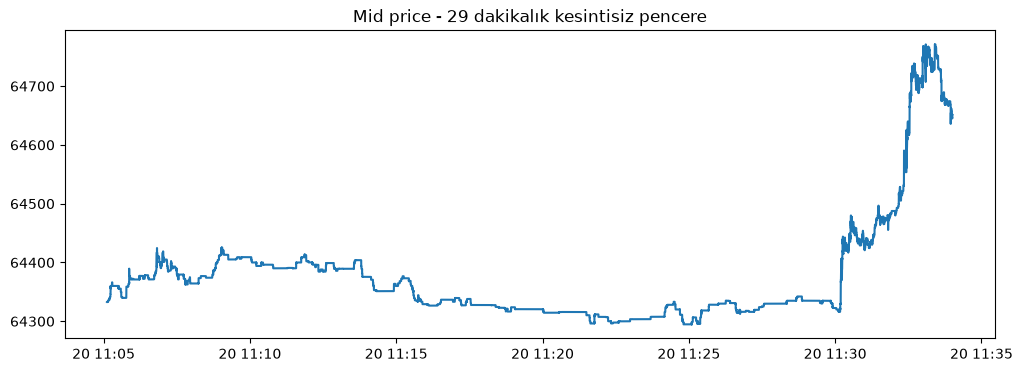

In [7]:
#29dklık kesintisiz veri: yatay sakin donem ardından yaklaşık 70 bpslik sert yükseliş trendi

book_df = book_df.sort_values('timestamp').reset_index(drop=True)
book_df['mid_price'] = (book_df['bid_0_price'] + book_df['ask_0_price']) / 2
book_df['spread'] = book_df['ask_0_price'] - book_df['bid_0_price']
book_df['spread_bps'] = (book_df['spread'] / book_df['mid_price']) * 10000

# Fiyat trendine hızlı bakış
import matplotlib.pyplot as plt
plt.figure(figsize=(12,4))
plt.plot(trades_df['datetime'], trades_df['price'])
plt.title("Mid price - 29 dakikalık kesintisiz pencere")
plt.show()

In [8]:
## Binance BTC-USDT perp'te gerçek spread çok dar: ortalama ~0.016 bps.

book_df = book_df.sort_values('timestamp').reset_index(drop=True)
book_df['mid_price'] = (book_df['bid_0_price'] + book_df['ask_0_price']) / 2
book_df['spread'] = book_df['ask_0_price'] - book_df['bid_0_price']
book_df['spread_bps'] = (book_df['spread'] / book_df['mid_price']) * 10000

print(f"Ortalama spread: {book_df['spread_bps'].mean():.4f} bps")
print(f"Min/Max spread: {book_df['spread_bps'].min():.4f} / {book_df['spread_bps'].max():.4f} bps")
book_df[['timestamp', 'bid_0_price', 'ask_0_price', 'mid_price', 'spread_bps']].head()

Ortalama spread: 0.0158 bps
Min/Max spread: 0.0154 / 0.8499 bps


,timestamp,bid_0_price,ask_0_price,mid_price,spread_bps
0,1784545506926,64332.5,64332.6,64332.55,0.015544
1,1784545507029,64332.5,64332.6,64332.55,0.015544
2,1784545507131,64332.5,64332.6,64332.55,0.015544
3,1784545507233,64332.5,64332.6,64332.55,0.015544
4,1784545507335,64332.5,64332.6,64332.55,0.015544


In [ ]:
# skew'siz sabit-spread ±5 bps sonucu (10 fill, 8 sell + 2 buy, -0.06 BTC, +2.18 USDT PnL)
# skew olmadan tüm fill'ler tek yöne yığılabiliyor - piyasa tek yönlü giderse market maker "trend'e karşı" pozisyon biriktiriyor (inventory risk)

half_spread_bps = 5
order_size = 0.01
max_inventory = 0.2   # gerçekçi bir üst sınır

inventory = 0.0
cash = 0.0
fills = []

for i in range(len(book_df) - 1):
    row = book_df.iloc[i]
    next_ts = book_df.iloc[i + 1]['timestamp']
    mid = row['mid_price']

    our_bid = mid * (1 - half_spread_bps / 10000)
    our_ask = mid * (1 + half_spread_bps / 10000)

    window_trades = trades_df[
        (trades_df['timestamp'] >= row['timestamp']) &
        (trades_df['timestamp'] < next_ts)
    ]

    filled_this_window = False  # bu pencerede zaten fill olduysak tekrar olmasın

    for _, t in window_trades.iterrows():
        if filled_this_window:
            break
        if t['side'] == 'sell' and t['price'] <= our_bid and inventory < max_inventory:
            inventory += order_size
            cash -= order_size * our_bid
            fills.append({'timestamp': t['timestamp'], 'side': 'buy', 'price': our_bid, 'inventory': inventory})
            filled_this_window = True
        elif t['side'] == 'buy' and t['price'] >= our_ask and inventory > -max_inventory:
            inventory -= order_size
            cash += order_size * our_ask
            fills.append({'timestamp': t['timestamp'], 'side': 'sell', 'price': our_ask, 'inventory': inventory})
            filled_this_window = True

fills_df = pd.DataFrame(fills)
current_mid = book_df.iloc[-1]['mid_price']
total_pnl = cash + inventory * current_mid

print(f"Toplam fill: {len(fills_df)}")
print(f"Buy fill: {(fills_df['side']=='buy').sum() if len(fills_df) else 0}")
print(f"Sell fill: {(fills_df['side']=='sell').sum() if len(fills_df) else 0}")
print(f"Son envanter: {inventory:.4f} BTC")
print(f"Nakit: {cash:.2f} USDT")
print(f"Toplam PnL (mark-to-market): {total_pnl:.2f} USDT")
fills_df.head(15)

Toplam fill: 10
Buy fill: 2
Sell fill: 8
Son envanter: -0.0600 BTC
Nakit: 3881.26 USDT
Toplam PnL (mark-to-market): 2.18 USDT


,timestamp,side,price,inventory
0,1784547140984,sell,64562.214975,-0.01
1,1784547146222,sell,64585.926825,-0.02
2,1784547146260,sell,64594.781250,-0.03
3,1784547156089,sell,64716.291975,-0.04
4,1784547179325,sell,64730.399025,-0.05
5,1784547185770,sell,64739.903775,-0.06
6,1784547185862,sell,64748.708175,-0.07
7,1784547203967,sell,64760.814225,-0.08
8,1784547217995,buy,64676.895375,-0.07
9,1784547236874,buy,64636.415625,-0.06


In [10]:
# skew'li sonuç (8 fill, 2 buy/6 sell, -0.04 BTC, +0.13 USDT PnL)

half_spread_bps = 5
order_size = 0.01
skew_factor = 0.3
max_inventory = 0.2

inventory = 0.0
cash = 0.0
fills = []

for i in range(len(book_df) - 1):
    row = book_df.iloc[i]
    next_ts = book_df.iloc[i + 1]['timestamp']
    mid = row['mid_price']

    inventory_skew = skew_factor * (inventory / max_inventory) * half_spread_bps
    our_bid = mid * (1 - (half_spread_bps + inventory_skew) / 10000)
    our_ask = mid * (1 + (half_spread_bps - inventory_skew) / 10000)

    window_trades = trades_df[
        (trades_df['timestamp'] >= row['timestamp']) &
        (trades_df['timestamp'] < next_ts)
    ]

    filled_this_window = False
    for _, t in window_trades.iterrows():
        if filled_this_window:
            break
        if t['side'] == 'sell' and t['price'] <= our_bid and inventory < max_inventory:
            inventory += order_size
            cash -= order_size * our_bid
            fills.append({'timestamp': t['timestamp'], 'side': 'buy', 'price': our_bid, 'inventory': inventory})
            filled_this_window = True
        elif t['side'] == 'buy' and t['price'] >= our_ask and inventory > -max_inventory:
            inventory -= order_size
            cash += order_size * our_ask
            fills.append({'timestamp': t['timestamp'], 'side': 'sell', 'price': our_ask, 'inventory': inventory})
            filled_this_window = True

fills_df_skewed = pd.DataFrame(fills)
current_mid = book_df.iloc[-1]['mid_price']
total_pnl_skewed = cash + inventory * current_mid

print(f"Toplam fill: {len(fills_df_skewed)}")
print(f"Buy: {(fills_df_skewed['side']=='buy').sum() if len(fills_df_skewed) else 0}, Sell: {(fills_df_skewed['side']=='sell').sum() if len(fills_df_skewed) else 0}")
print(f"Son envanter: {inventory:.4f} BTC")
print(f"Nakit: {cash:.2f} USDT")
print(f"Toplam PnL (skew'li): {total_pnl_skewed:.2f} USDT")

Toplam fill: 8
Buy: 2, Sell: 6
Son envanter: -0.0400 BTC
Nakit: 2586.18 USDT
Toplam PnL (skew'li): 0.13 USDT


In [ ]:
# envantere göre quote'ları kaydırmak (skew_factor 0→3 taraması) net bir trade-off gösterdi: 
# skew arttıkça envanter dengeleniyor (-0.06 → -0.01 BTC) ama PnL geriliyor, hatta 1.5+ değerlerinde negatife dönüyor.

# envanteri fazla sıkı kontrol etmenin bedeli kâr kaybı

def run_simulation(skew_factor, half_spread_bps=5, order_size=0.01, max_inventory=0.2):
    inventory = 0.0
    cash = 0.0
    fills = []

    for i in range(len(book_df) - 1):
        row = book_df.iloc[i]
        next_ts = book_df.iloc[i + 1]['timestamp']
        mid = row['mid_price']

        inventory_skew = skew_factor * (inventory / max_inventory) * half_spread_bps
        our_bid = mid * (1 - (half_spread_bps + inventory_skew) / 10000)
        our_ask = mid * (1 + (half_spread_bps - inventory_skew) / 10000)

        window_trades = trades_df[
            (trades_df['timestamp'] >= row['timestamp']) &
            (trades_df['timestamp'] < next_ts)
        ]

        filled_this_window = False
        for _, t in window_trades.iterrows():
            if filled_this_window:
                break
            if t['side'] == 'sell' and t['price'] <= our_bid and inventory < max_inventory:
                inventory += order_size
                cash -= order_size * our_bid
                fills.append({'side': 'buy', 'price': our_bid})
                filled_this_window = True
            elif t['side'] == 'buy' and t['price'] >= our_ask and inventory > -max_inventory:
                inventory -= order_size
                cash += order_size * our_ask
                fills.append({'side': 'sell', 'price': our_ask})
                filled_this_window = True

    current_mid = book_df.iloc[-1]['mid_price']
    pnl = cash + inventory * current_mid
    buy_count = sum(1 for f in fills if f['side'] == 'buy')
    sell_count = sum(1 for f in fills if f['side'] == 'sell')

    return {
        'skew_factor': skew_factor,
        'total_fills': len(fills),
        'buy_fills': buy_count,
        'sell_fills': sell_count,
        'final_inventory': inventory,
        'cash': cash,
        'pnl': pnl
    }

skew_values = [0.0, 0.3, 0.5, 1.0, 1.5, 2.0, 3.0]
results = [run_simulation(s) for s in skew_values]
results_df = pd.DataFrame(results)
results_df

,skew_factor,total_fills,buy_fills,sell_fills,final_inventory,cash,pnl
0,0.0,10,2,8,-0.06,3881.257292,2.176292
1,0.3,8,2,6,-0.04,2586.181453,0.127453
2,0.5,8,2,6,-0.04,2586.194376,0.140376
3,1.0,8,2,6,-0.04,2586.226684,0.172684
4,1.5,7,2,5,-0.03,1939.023292,-0.517208
5,2.0,7,2,5,-0.03,1939.031339,-0.509161
6,3.0,9,4,5,-0.01,644.544953,-1.968547


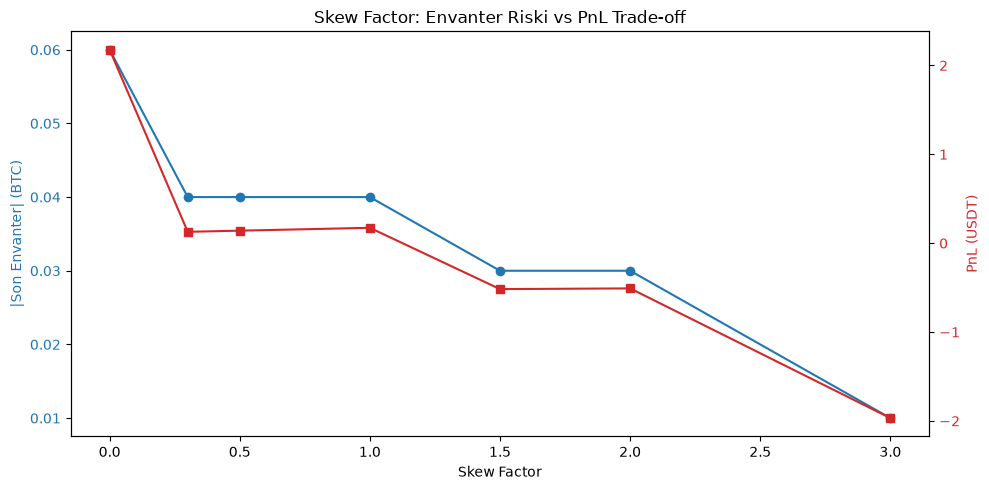

In [13]:
# skew ekledikçe hem risk hem kâr birlikte azalıyor
# optimal bölge: skew_factor ≈ 0.5-1.0 — makul envanter kontrolü + pozitif PnL.

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(results_df['skew_factor'], results_df['final_inventory'].abs(), 'o-', color='tab:blue', label='|Envanter|')
ax1.set_xlabel('Skew Factor')
ax1.set_ylabel('|Son Envanter| (BTC)', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.plot(results_df['skew_factor'], results_df['pnl'], 's-', color='tab:red', label='PnL')
ax2.set_ylabel('PnL (USDT)', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Skew Factor: Envanter Riski vs PnL Trade-off')
fig.tight_layout()
plt.show()

In [14]:
# Avellaneda-Stoikov Modeli - Volatilite (σ)

import numpy as np

book_df['log_return'] = np.log(book_df['mid_price'] / book_df['mid_price'].shift(1))
sigma = book_df['log_return'].std()
print(f"Snapshot-bazlı volatilite (σ): {sigma:.8f}")

# Saniyelik volatiliteye çevirelim (snapshot'lar ~100ms aralıklı)
avg_dt_sec = book_df['timestamp'].diff().mean() / 1000
sigma_per_sec = sigma / np.sqrt(avg_dt_sec)
print(f"Ortalama snapshot aralığı: {avg_dt_sec:.4f} saniye")
print(f"Saniyelik volatilite: {sigma_per_sec:.6f}")

Snapshot-bazlı volatilite (σ): 0.00002131
Ortalama snapshot aralığı: 0.1095 saniye
Saniyelik volatilite: 0.000064


In [15]:
# Avellaneda-Stoikov Modeli - likidite yoğunluğu (κ)


# Her trade'in gerçekleştiği andaki mid price'ı bulup, trade fiyatının mid'den uzaklığını (bps) hesaplayalım
book_sorted = book_df.sort_values('timestamp')
trades_sorted = trades_df.sort_values('timestamp')

merged = pd.merge_asof(trades_sorted, book_sorted[['timestamp', 'mid_price']], on='timestamp', direction='backward')
merged['distance_bps'] = ((merged['price'] - merged['mid_price']).abs() / merged['mid_price']) * 10000

# Basit kappa tahmini: distance_bps'in ortalamasının tersi ile orantılı bir yaklaşım
# (Not: tam doğru kappa fit'i log-linear regresyon gerektirir, burada basitleştirilmiş bir tahmin kullanıyoruz)
avg_distance = merged['distance_bps'].mean()
kappa = 1 / avg_distance if avg_distance > 0 else 1.0

print(f"Ortalama trade-mid mesafesi: {avg_distance:.6f} bps")
print(f"Tahmini kappa: {kappa:.4f}")

Ortalama trade-mid mesafesi: 0.852390 bps
Tahmini kappa: 1.1732


In [16]:
# dolar cinsinden


# Volatiliteyi dolar cinsinden (log-return değil, fiyat farkı olarak) hesaplayalım
book_df['price_diff'] = book_df['mid_price'].diff()
sigma_dollar = book_df['price_diff'].std() / np.sqrt(avg_dt_sec)
print(f"Dolar cinsinden saniyelik volatilite: {sigma_dollar:.6f} USDT")

# Kappa'yı da dolar cinsinden mesafeyle yeniden hesaplayalım
merged['distance_dollar'] = (merged['price'] - merged['mid_price']).abs()
avg_distance_dollar = merged['distance_dollar'].mean()
kappa_dollar = 1 / avg_distance_dollar
print(f"Ortalama trade-mid mesafesi: {avg_distance_dollar:.4f} USDT")
print(f"Yeniden hesaplanan kappa: {kappa_dollar:.6f}")

Dolar cinsinden saniyelik volatilite: 4.159822 USDT
Ortalama trade-mid mesafesi: 5.5048 USDT
Yeniden hesaplanan kappa: 0.181661


In [17]:
# gamma (risk aversion): 
# düşük gamma → çok fill, yüksek risk, zarar
# yüksek gamma → az fill, dengeli envanter, pozitif PnL

def run_avellaneda_stoikov(gamma, sigma, kappa, order_size=0.01, max_inventory=0.2):
    inventory = 0.0
    cash = 0.0
    fills = []

    total_duration_sec = (book_df['timestamp'].iloc[-1] - book_df['timestamp'].iloc[0]) / 1000

    for i in range(len(book_df) - 1):
        row = book_df.iloc[i]
        next_ts = book_df.iloc[i + 1]['timestamp']
        mid = row['mid_price']

        elapsed_sec = (row['timestamp'] - book_df['timestamp'].iloc[0]) / 1000
        remaining_time = max(total_duration_sec - elapsed_sec, 1)

        reservation_price = mid - inventory * gamma * (sigma**2) * remaining_time
        optimal_spread = gamma * (sigma**2) * remaining_time + (2/gamma) * np.log(1 + gamma/kappa)

        our_bid = reservation_price - optimal_spread / 2
        our_ask = reservation_price + optimal_spread / 2

        window_trades = trades_df[
            (trades_df['timestamp'] >= row['timestamp']) &
            (trades_df['timestamp'] < next_ts)
        ]

        filled_this_window = False
        for _, t in window_trades.iterrows():
            if filled_this_window:
                break
            if t['side'] == 'sell' and t['price'] <= our_bid and inventory < max_inventory:
                inventory += order_size
                cash -= order_size * our_bid
                fills.append({'side': 'buy'})
                filled_this_window = True
            elif t['side'] == 'buy' and t['price'] >= our_ask and inventory > -max_inventory:
                inventory -= order_size
                cash += order_size * our_ask
                fills.append({'side': 'sell'})
                filled_this_window = True

    current_mid = book_df.iloc[-1]['mid_price']
    pnl = cash + inventory * current_mid
    buy_count = sum(1 for f in fills if f['side'] == 'buy')
    sell_count = sum(1 for f in fills if f['side'] == 'sell')

    return {
        'gamma': gamma,
        'total_fills': len(fills),
        'buy_fills': buy_count,
        'sell_fills': sell_count,
        'final_inventory': inventory,
        'cash': cash,
        'pnl': pnl
    }

gamma_values = [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1]
as_results = [run_avellaneda_stoikov(g, sigma_dollar, kappa_dollar) for g in gamma_values]
as_results_df = pd.DataFrame(as_results)
as_results_df

,gamma,total_fills,buy_fills,sell_fills,final_inventory,cash,pnl
0,0.0001,142,62,80,-0.18,11584.460761,-52.782239
1,0.0005,120,51,69,-0.18,11590.833722,-46.409278
2,0.0010,110,47,63,-0.16,10310.310251,-33.905749
3,0.0050,54,21,33,-0.12,7752.043457,-6.118543
4,0.0100,38,15,23,-0.08,5173.509307,1.401307
5,0.0500,14,4,10,-0.06,3879.703559,0.622559
6,0.1000,5,2,3,-0.01,647.134508,0.621008


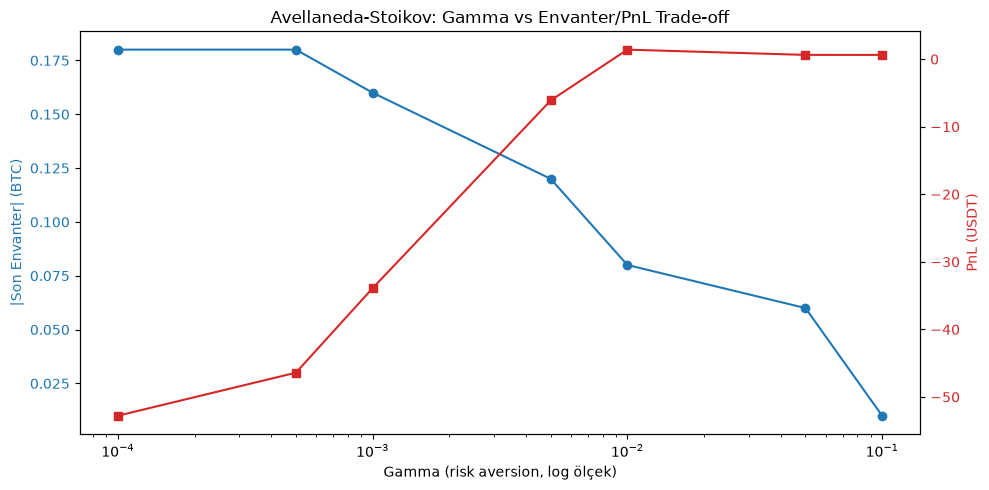

In [18]:
# gamma ≈ 0.01 civarı ilk kez pozitif PnL ile makul envanteri bir arada verdi — equilibrium

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(as_results_df['gamma'], as_results_df['final_inventory'].abs(), 'o-', color='tab:blue')
ax1.set_xscale('log')
ax1.set_xlabel('Gamma (risk aversion, log ölçek)')
ax1.set_ylabel('|Son Envanter| (BTC)', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.plot(as_results_df['gamma'], as_results_df['pnl'], 's-', color='tab:red')
ax2.set_ylabel('PnL (USDT)', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Avellaneda-Stoikov: Gamma vs Envanter/PnL Trade-off')
fig.tight_layout()
plt.show()

In [12]:
# Hem basit skew hem de matematiksel AS modeli aynı temel gerçeği farklı şekillerde kanıtladı: 
# market making'te risk azaltma (envanter kontrolü) ile kâr maksimizasyonu birbirine ters yönde çekiyor. 
# AS modelinin üstünlüğü, bu dengeyi keyfi bir sabit yerine piyasa koşullarına (volatilite, kalan zaman) duyarlı şekilde kurması.